<a href="https://colab.research.google.com/github/FX9919/Final-project-used-car-analysis/blob/main/Final_project_used_car__Analyse_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this notebook  I will explain what makes a car overpriced or underpriced?

---


بي معنى متى تكون السياره اعلى من السعر المتوقع و اقل من السعر المفترض؟

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
df = pd.read_csv('vehicles_features.csv')

In [63]:
df['expected_price'] = df.groupby('odometer')['price'].transform('mean')
print(df['expected_price']) # get average price for cars with same mileage
#-------------------------------------------------------------------------
#هنا حسبت السعر المتوقع بناء على عدد الكيلومتر الي كشته السياره

0      14220.16
1      14220.16
2      14220.16
3      14220.16
4      14220.16
         ...   
937    15108.00
938    14577.00
939    19477.00
940    35990.00
941    14220.16
Name: expected_price, Length: 942, dtype: float64


In [64]:
df['price_diff'] = df['price'] - df['expected_price']
print(df['price_diff'])# to see the difference between the real price and expected price
# negative values mean  cheaper than expected or underpriced cars
#-----------------------------------------------------------------------------------------
#الفرق ببن السعر الجقيقي و المتوقع

0      -8220.16
1      -2320.16
2       6779.84
3     -12720.16
4      -9320.16
         ...   
937        0.00
938        0.00
939        0.00
940        0.00
941     2748.84
Name: price_diff, Length: 942, dtype: float64


In [65]:
df['price_diff_abs'] = df['price_diff'].abs()
print(df['price_diff_abs']) # how big the price difference is
#-------------------------------------------------------------
#حجم الفرق بين السعر الحقيقي و المتوقع

0       8220.16
1       2320.16
2       6779.84
3      12720.16
4       9320.16
         ...   
937        0.00
938        0.00
939        0.00
940        0.00
941     2748.84
Name: price_diff_abs, Length: 942, dtype: float64


In [66]:
# df['price_status'] = df['price_diff_abs'].apply(lambda x: 'overpriced' if x > 0 else 'underpriced')
df['price_status'] = np.where(df['price_diff'] > 0, 'overpriced', 'underpriced')
print(df['price_status'])# to see the difference between the real price and expected price
#--------------------------------------------------------------------------------------------------
#اذا السعر اعلى من المتوقع = overpriced
# اذا اقل = underpriced

0      underpriced
1      underpriced
2       overpriced
3      underpriced
4      underpriced
          ...     
937    underpriced
938    underpriced
939    underpriced
940    underpriced
941     overpriced
Name: price_status, Length: 942, dtype: object


/tmp/ipykernel_36539/803875797.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='price_status', data=df,palette='Pastel1')


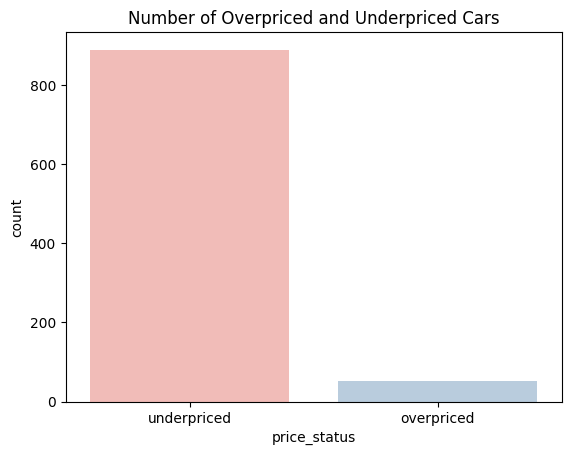

In [67]:
sns.countplot(x='price_status', data=df,palette='Pastel1')
plt.title('Number of Overpriced and Underpriced Cars')
plt.show()# I see how many cars are overpriced vs underpriced
#------------------------------------------------------------
# هنا عشان اشوف كم سيارع غاليه مقارنه بسيارات الرخيصه

/tmp/ipykernel_36539/306265502.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='price_status', y='car_age', data=df, palette='Pastel1')


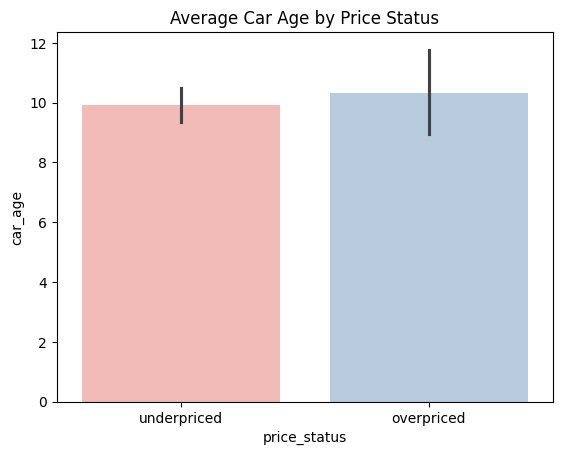

In [68]:
sns.barplot(x='price_status', y='car_age', data=df, palette='Pastel1')
plt.title('Average Car Age by Price Status')
plt.show()
# I compare the average age between overpriced and underpriced cars
# I see that underpriced cars are usually older
#-----------------------------------------------------------------------
# يوضح متوسط عمر السيارات حسب السعر (غالية أو رخيصة)

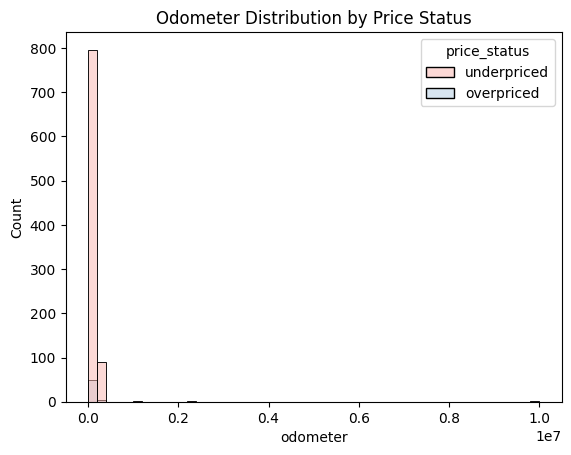

In [69]:
sns.histplot(x='odometer', data=df, hue='price_status', bins=50, palette='Pastel1')
plt.title('Odometer Distribution by Price Status')
plt.show()

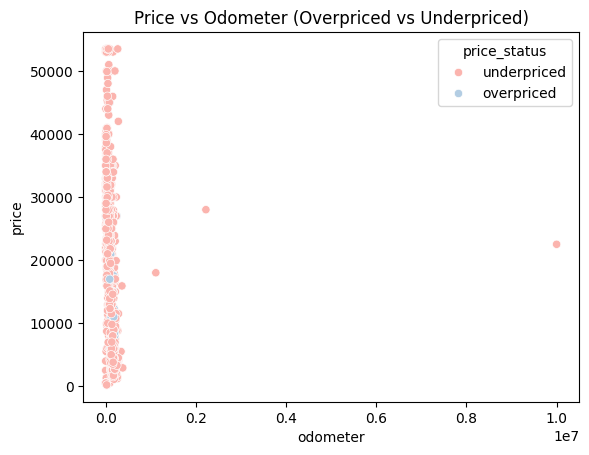

In [70]:
sns.scatterplot(x=df['odometer'], y=df['price'], hue=df['price_status'], palette='Pastel1')
plt.title('Price vs Odometer (Overpriced vs Underpriced)')
plt.show()
# I see how overpriced and underpriced cars are distributed
# overpriced cars tend to have lower mileage

/tmp/ipykernel_36539/3928117607.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='price', data=df, ax=axes[1,0], palette='pastel')


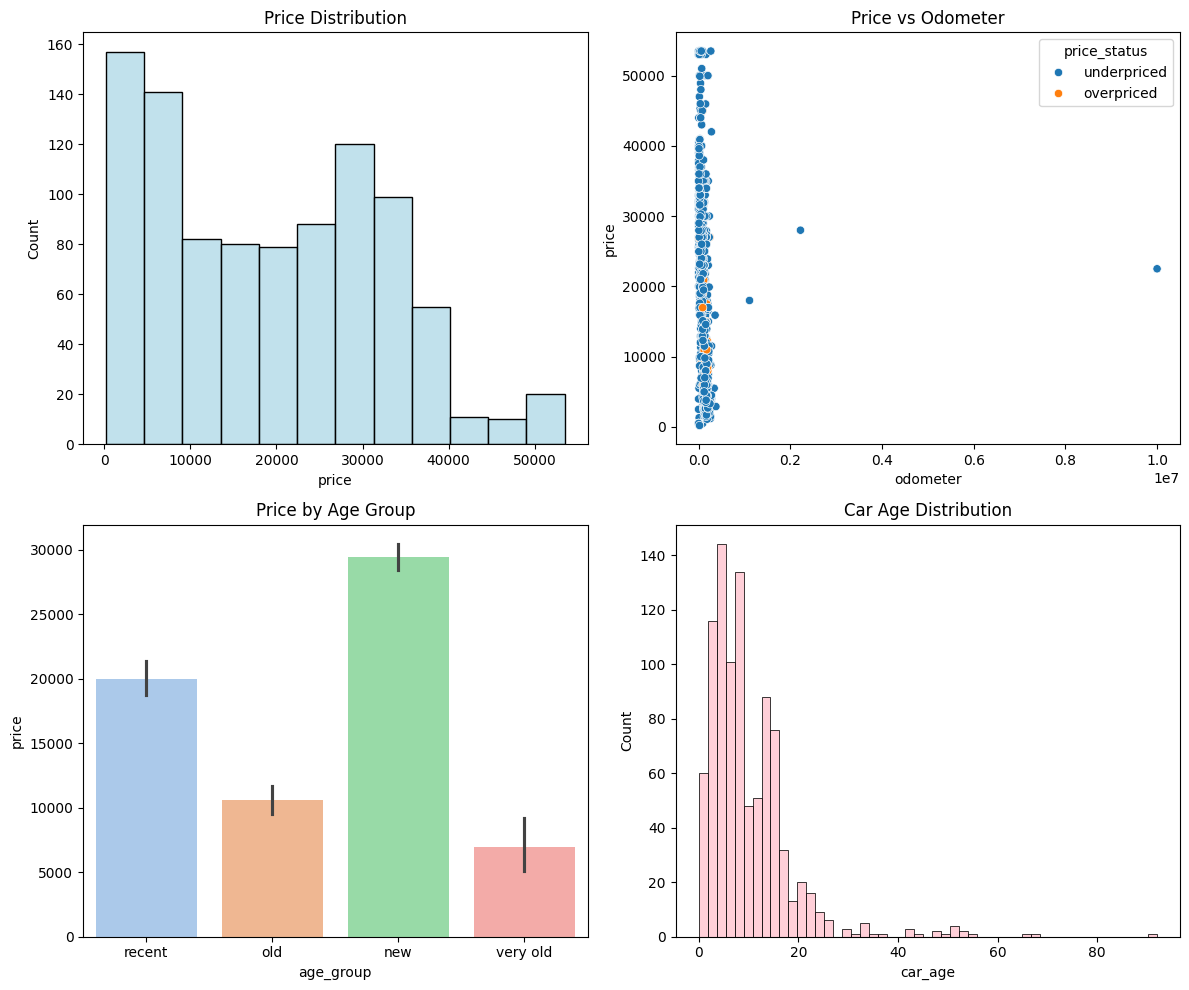

In [72]:
fig, axes = plt.subplots(2,2, figsize=(12,10))

# رسم 1
sns.histplot(df['price'], ax=axes[0,0], color='lightblue')
axes[0,0].set_title('Price Distribution')

# رسم 2
sns.scatterplot(x=df['odometer'], y=df['price'],hue=df['price_status'] , ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Price vs Odometer')

# رسم 3
sns.barplot(x='age_group', y='price', data=df, ax=axes[1,0], palette='pastel')
axes[1,0].set_title('Price by Age Group')

# رسم 4
sns.histplot(df['car_age'], ax=axes[1,1], color='pink')
axes[1,1].set_title('Car Age Distribution')

plt.tight_layout()
plt.show()
# this dashboard shows multiple views of the data in one place
# هنا جمعت اكثر من رسمه مع بعض عشان اشوف البيانات بشكل شامل


soo from theis analysis I saw that price depends on mileage and age and Overpriced cars usually have low mileage or better condition Underpriced cars are often older or have higher mileage So, price is affected by multiple factors together.
